In [22]:
# Cell 1: 导入库
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Cell 2: 定义模型（必须和训练时一样）
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout(0.25)
        self.dropout2 = nn.Dropout(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return F.log_softmax(x, dim=1)

# Cell 3: 加载模型
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = Net().to(device)
model.load_state_dict(torch.load('mnist_model.pth', map_location=device, weights_only=False))
model.eval()
print("模型加载成功")

# Cell 4: 准备测试数据
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)
testloader = DataLoader(testset, batch_size=500, shuffle=False)
test_images, test_labels = next(iter(testloader))

# Cell 5: 取第八张图片推理
img = test_images[7]
true_label = test_labels[7].item()

with torch.no_grad():
    img_tensor = img.unsqueeze(0).to(device)
    output = model(img_tensor)
    _, predicted = torch.max(output, 1)
    predicted_label = predicted[0].item()

# print(type(predicted[0]))
print(f"预测结果: {predicted_label}")
print(f"真实标签: {true_label}")

模型加载成功
预测结果: 9
真实标签: 9


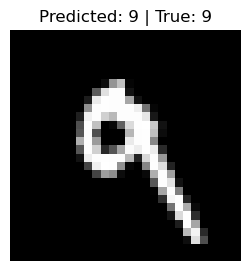

In [23]:
# Cell 6: 显示图片
plt.figure(figsize=(3, 3))
plt.imshow(img.squeeze(), cmap='gray')
plt.title(f"Predicted: {predicted_label} | True: {true_label}")
plt.axis('off')
plt.show()

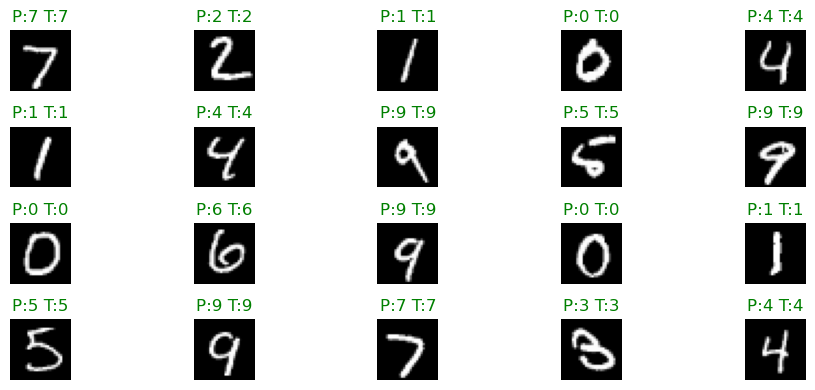

测试集准确率: 98.90%


In [24]:
# Cell 7: 测试前10张图片
fig, axes = plt.subplots(4, 5, figsize=(10, 4))
axes = axes.flatten()

for i in range(20):
    img = test_images[i]
    true_label = test_labels[i].item()
    
    with torch.no_grad():
        img_tensor = img.unsqueeze(0).to(device)
        output = model(img_tensor)
        _, predicted = torch.max(output, 1)
        predicted_label = predicted[0].item()
    
    axes[i].imshow(img.squeeze(), cmap='gray')
    color = 'green' if predicted_label == true_label else 'red'
    axes[i].set_title(f"P:{predicted_label} T:{true_label}", color=color)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Cell 8: 计算整体准确率
correct = 0
total = 0

with torch.no_grad():
    for images, labels in testloader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

print(f"测试集准确率: {100 * correct / total:.2f}%")

### 为什么推理时要写 model.eval()？
- 使用model.eval()能让模型从training模式进入evaluation模式。
- 补充：它会关闭 Dropout 和 BatchNorm 的训练行为。
### torch.no_grad() 是做什么的？
- 在evaluation模式中，不需要计算gradient。使用torch.no_grad()可以提升evaluation模式中的运行速度。
- 补充：还能节省显存。
### 如果你的预测结果全是同一个数字，可能是什么原因？
- 可能说明模型训练的时候的数据多样性不够，例如说其中某一个数字的数量过于多。
- 补充：也可能是忘记写 model.eval() 导致 Dropout 还在工作